# 07 - Model Training Random Forest

**Mục tiêu:** Huấn luyện mô hình Random Forest trên tập vector TF-IDF của bộ dữ liệu ISOT. Quá trình bao gồm việc sử dụng `GridSearchCV` để tìm ra bộ siêu tham số tốt nhất (Hyperparameter tuning) và sau đó lưu trữ mô hình ra dạng file `.pkl` để sử dụng ở các phase tiếp theo (Phase 5, 8).

In [21]:
import pandas as pd
import numpy as np
import pickle
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
# 1. Load Data
print('Loading TF-IDF features...')
X_train = joblib.load('../data/X_train_tfidf.pkl')
y_train = joblib.load('../data/y_train.pkl')
X_val = joblib.load('../data/X_val_tfidf.pkl')
y_val = joblib.load('../data/y_val.pkl')

print(f'Train shape: {X_train.shape}')
print(f'Val shape: {X_val.shape}')

Loading TF-IDF features...
Train shape: (27057, 5000)
Val shape: (5798, 5000)


### 2. Thiết lập GridSearchCV cho Random Forest

Cấu hình thử nghiệm theo kế hoạch master-plan:
- `n_estimators`: [100, 200, 300] (Số lượng cây quyết định)
- `max_depth`: [None, 10, 20] (Độ sâu tối đa của cây)
- `min_samples_split`: [2, 5] (Số lượng mẫu tối thiểu để tách một node)

In [ ]:
# 2. Define Model and Parameters for GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, scoring='f1_weighted', n_jobs=-1, verbose=2)

print('Bắt đầu training GridSearchCV (Random Forest chạy trên TF-IDF mất khoảng nửa tiếng)...')
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f'Training time: {time.time() - start_time:.2f} seconds')

Bắt đầu training GridSearchCV (Sẽ tốn khá nhiều thời gian vì Random Forest chạy trên TF-IDF rất nặng)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Training time: 1687.11 seconds


In [24]:
# 3. Đánh giá mô hình tốt nhất (Best Model Evaluation)
print('Best parameters:', grid_search.best_params_)
best_rf = grid_search.best_estimator_

print('\nDự đoán trên tập Validation...')
y_pred = best_rf.predict(X_val)

print('\n--- Classification Report ---')
print(classification_report(y_val, y_pred))

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}

Dự đoán trên tập Validation...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3179
           1       0.99      0.97      0.98      2619

    accuracy                           0.98      5798
   macro avg       0.98      0.98      0.98      5798
weighted avg       0.98      0.98      0.98      5798



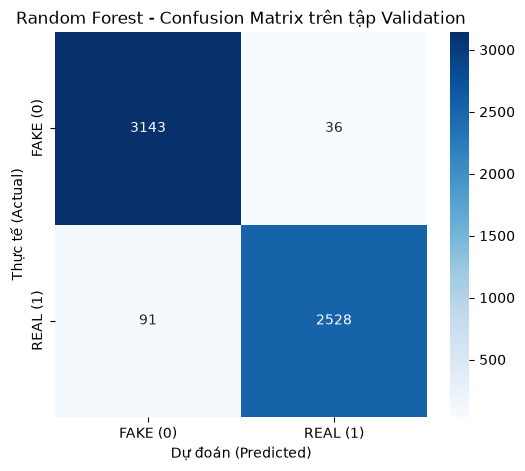

In [25]:
# 4. Vẽ Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['FAKE (0)', 'REAL (1)'], 
            yticklabels=['FAKE (0)', 'REAL (1)'])
plt.ylabel('Thực tế (Actual)')
plt.xlabel('Dự đoán (Predicted)')
plt.title('Random Forest - Confusion Matrix trên tập Validation')

import os
if not os.path.exists('../reports'):
    os.makedirs('../reports')
plt.savefig('../reports/rf_confusion_matrix.png', bbox_inches='tight')
plt.show()

### 5. Lưu Mô Hình (Model Persistence)

Lưu lại model tốt nhất bằng `joblib` để sử dụng ở các bước tiếp theo mà không cần phải train lại.

In [26]:
# 5. Save the best model
if not os.path.exists('../models'):
    os.makedirs('../models')
model_path = '../models/rf_model.pkl'
joblib.dump(best_rf, model_path)
print(f'Model đã được lưu thành công tại: {model_path}')

Model đã được lưu thành công tại: ../models/rf_model.pkl
